# Prediksi Kawasan Kumuh (Slum) - Indikator 1: Bangunan (Versi Perbaikan)

Klasifikasi biner area **Slum (1)** vs **Non-Slum (0)** dengan **XGBoost**, hanya memakai
fitur **bangunan**. Versi ini memperbaiki seluruh masalah kritis pada eksperimen 4 sebelumnya.

### Perbaikan yang diterapkan
1. **`city` BUKAN fitur lagi.** OneHotEncoder untuk `city` dihapus. `city` hanya dipakai untuk
   *grouping* saat validasi. Ini menjaga model benar-benar murni "indikator bangunan" dan
   mencegah model menempuh jalan pintas prevalensi per-kota.
2. **`StandardScaler` dihapus.** XGBoost (pohon) kebal terhadap skala, jadi scaling tidak perlu.
3. **Validasi spasial Leave-One-City-Out (LOCO)** menggantikan `train_test_split` acak. Split acak
   membocorkan autokorelasi spasial antar-kelurahan dan menggelembungkan skor.
4. **Metrik utama PR-AUC + recall** (bukan accuracy/ROC-AUC) karena data sangat timpang (~14% slum).
5. **Threshold dioptimalkan** dari prediksi out-of-fold, bukan dipatok 0.5.
6. **Seleksi fitur dievaluasi ulang dengan bukti (ablation)**: apakah 14 fitur sudah cukup atau
   justru membuang informasi bangunan (lihat Bagian 5).
7. **Imputasi median di dalam `Pipeline`** sehingga di-fit per-fold (anti-leakage).

## 1. Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (LeaveOneGroupOut, GroupKFold, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import (classification_report, confusion_matrix, average_precision_score,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             recall_score, f1_score)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

## 2. Data Loading & Definisi Fitur Bangunan (Anti-Leakage)

Dari 38 kolom, kita pisahkan secara eksplisit menjadi 4 kelompok. Hanya kelompok **bangunan**
yang masuk ke model. `city` dan identitas/ukuran unit **tidak** dipakai sebagai fitur.

In [3]:
df = pd.read_csv('../data/processed/features_buildings.csv')
print("Dimensi data mentah:", df.shape)

# --- META: jangan pernah jadi fitur ---
META = ['slum', 'city', 'unit_id', 'unit_area_m2']

# --- Kelompok bangunan inti: geometri & morfologi footprint bangunan ---
CORE_BUILDING = [
    'b_area_mean', 'b_area_median', 'b_area_std', 'b_area_sum',
    'b_count', 'b_coverage', 'b_density_km2', 'b_size_cv',
    'building_fractional_count_mean', 'building_fractional_count_stdDev',
    'building_height_mean', 'building_height_stdDev',
    'building_presence_mean', 'building_presence_stdDev',
]

# --- NDBI = Normalized Difference BUILT-UP Index + tekstur GLCM-nya ---
# NDBI adalah indeks kawasan terbangun; tekstur (contrast/entropy/variance) menangkap
# keteraturan vs kekacauan morfologi bangunan (ciri khas pembeda slum).
BUILTUP_TEXTURE = [
    'ndbi_mean', 'ndbi_stdDev',
    'ndbi_contrast_mean', 'ndbi_contrast_stdDev',
    'ndbi_ent_mean', 'ndbi_ent_stdDev',
    'ndbi_var_mean', 'ndbi_var_stdDev',
]

# --- BUKAN indikator bangunan (sengaja dikecualikan, lihat alasannya) ---
NON_BUILDING = {
    'SAR radar (Sentinel-1)': ['VH_mean','VH_stdDev','VV_mean','VV_stdDev','vv_vh_mean','vv_vh_stdDev'],
    'Kecerahan optik':        ['brightness_mean','brightness_stdDev'],
    'Bare Soil Index (tanah)':['bsi_mean','bsi_stdDev'],
    'NDVI (vegetasi)':        ['ndvi_mean','ndvi_stdDev'],
}

# Jaga-jaga: hanya pakai kolom yang benar-benar ada
CORE_BUILDING   = [c for c in CORE_BUILDING   if c in df.columns]
BUILTUP_TEXTURE = [c for c in BUILTUP_TEXTURE if c in df.columns]

print(f"Bangunan inti (footprint)      : {len(CORE_BUILDING)} fitur")
print(f"NDBI built-up + tekstur        : {len(BUILTUP_TEXTURE)} fitur")
print("Dikecualikan (indikator lain)  :")
for grp, cols in NON_BUILDING.items():
    print(f"   - {grp}: {[c for c in cols if c in df.columns]}")

y = df['slum'].astype(int).values
groups = df['city'].values
print(f"\nPrevalensi slum: {y.mean():.3f}  (positif={int(y.sum())} / total={len(y)})")
print("Kota:", sorted(pd.unique(groups)))

Dimensi data mentah: (828, 38)
Bangunan inti (footprint)      : 14 fitur
NDBI built-up + tekstur        : 8 fitur
Dikecualikan (indikator lain)  :
   - SAR radar (Sentinel-1): ['VH_mean', 'VH_stdDev', 'VV_mean', 'VV_stdDev', 'vv_vh_mean', 'vv_vh_stdDev']
   - Kecerahan optik: ['brightness_mean', 'brightness_stdDev']
   - Bare Soil Index (tanah): ['bsi_mean', 'bsi_stdDev']
   - NDVI (vegetasi): ['ndvi_mean', 'ndvi_stdDev']

Prevalensi slum: 0.143  (positif=118 / total=828)
Kota: ['ambon', 'dki', 'kebumen', 'samarinda']


## 3. Exploratory Data Analysis (EDA)
Sebaran target, kepadatan bangunan, dan keterkaitan cakupan vs tinggi bangunan.

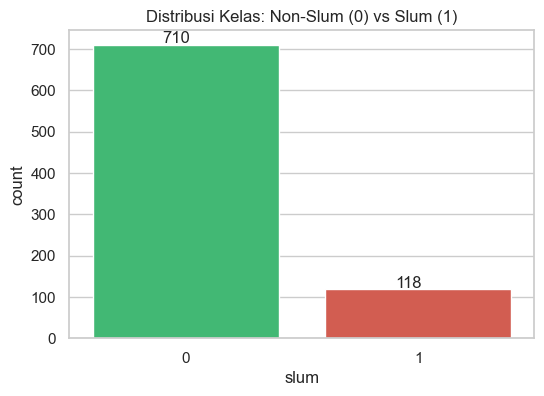

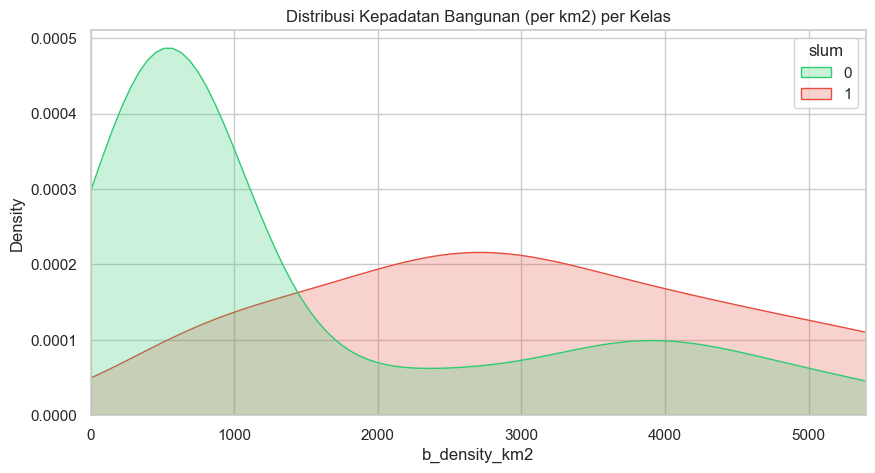

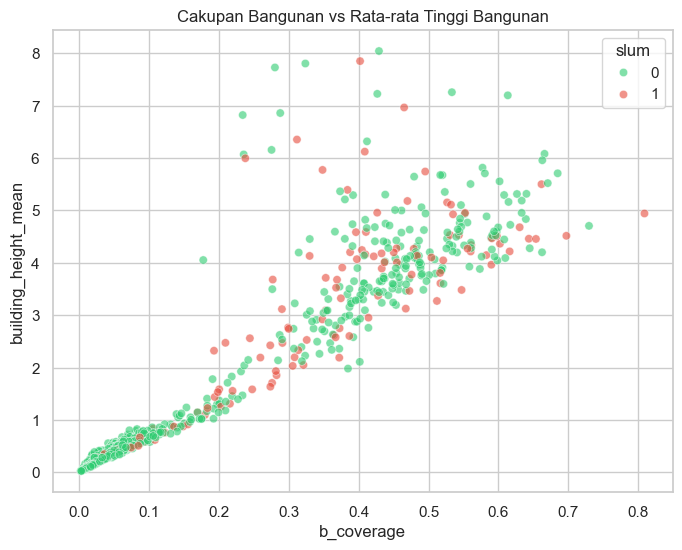

In [4]:
# Graf 1: Distribusi kelas
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='slum', hue='slum',
                   palette={0:'#2ecc71', 1:'#e74c3c'}, legend=False)
plt.title('Distribusi Kelas: Non-Slum (0) vs Slum (1)')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.30, p.get_height()+5))
plt.show()

# Graf 2: Kepadatan bangunan per km2 per kelas
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='b_density_km2', hue='slum', fill=True, common_norm=False,
            palette={0:'#2ecc71', 1:'#e74c3c'})
plt.title('Distribusi Kepadatan Bangunan (per km2) per Kelas')
plt.xlim(0, df['b_density_km2'].quantile(0.95))
plt.show()

# Graf 3: Cakupan vs rata-rata tinggi bangunan
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='b_coverage', y='building_height_mean', hue='slum',
                alpha=0.6, palette={0:'#2ecc71', 1:'#e74c3c'})
plt.title('Cakupan Bangunan vs Rata-rata Tinggi Bangunan')
plt.show()

## 4. Strategi Validasi: Leave-One-City-Out (LOCO)

**Kenapa bukan `train_test_split` acak?** Dengan hanya ~828 baris dan 4 kota, split acak
menaruh kelurahan-kelurahan bertetangga yang sangat mirip di train **dan** test sekaligus
(autokorelasi spasial), sehingga skor terlihat tinggi tapi semu. LOCO melatih pada 3 kota
dan menguji pada kota ke-4 -- memaksa model menggeneralisasi ke kota yang belum pernah dilihat,
persis kondisi pemakaian nyata. Tabel di bawah memperlihatkan komposisi tiap fold.

In [5]:
# Komposisi tiap fold LOCO
fold_rows = []
for tr, te in LeaveOneGroupOut().split(np.zeros(len(y)), y, groups):
    fold_rows.append({"kota_validasi": groups[te][0],
                      "kota_latih": ", ".join(sorted(np.unique(groups[tr]))),
                      "n_latih": len(tr), "slum_latih": int(y[tr].sum()),
                      "n_validasi": len(te), "slum_validasi": int(y[te].sum())})
print(pd.DataFrame(fold_rows).to_string(index=False))

# --- Pembuat model XGBoost (tanpa scaler, tanpa onehot; imputasi di dalam pipeline) ---
def make_xgb(spw, **params):
    p = dict(n_estimators=400, max_depth=4, learning_rate=0.05,
             subsample=0.85, colsample_bytree=0.85, reg_lambda=2.0, min_child_weight=2,
             scale_pos_weight=spw, objective='binary:logistic', eval_metric='aucpr',
             n_jobs=-1, random_state=RANDOM_STATE, verbosity=0)
    p.update(params)
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                     ('clf', XGBClassifier(**p))])

# --- Prediksi out-of-fold LOCO: tiap kota diprediksi model yang dilatih kota lain saja ---
def loco_oof(feature_cols, params=None):
    params = params or {}
    X = df[feature_cols]
    oof = np.zeros(len(y))
    for tr, te in LeaveOneGroupOut().split(X, y, groups):
        spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
        est = make_xgb(spw, **params).fit(X.iloc[tr], y[tr])
        oof[te] = est.predict_proba(X.iloc[te])[:, 1]
    return oof

kota_validasi                kota_latih  n_latih  slum_latih  n_validasi  slum_validasi
        ambon   dki, kebumen, samarinda      778         103          50             15
          dki ambon, kebumen, samarinda      567          56         261             62
      kebumen     ambon, dki, samarinda      370          91         458             27
    samarinda       ambon, dki, kebumen      769         104          59             14


## 5. Evaluasi Ulang Seleksi Fitur -- Apakah 14 Fitur Membuang Informasi?

Pertanyaan kuncinya: memilih hanya 14 fitur footprint bangunan -- apakah benar, atau justru
membuang informasi? Kita jawab dengan **bukti** (ablation LOCO), bukan opini: bandingkan PR-AUC
dua himpunan fitur.

- **Bangunan inti (14)** -- hanya geometri footprint bangunan.
- **Bangunan inti + NDBI built-up (22)** -- menambah indeks kawasan terbangun & teksturnya.

Indikator non-bangunan (SAR, kecerahan, BSI, NDVI) tetap dikecualikan agar definisi
"Indikator 1: Bangunan" tidak bocor ke indikator lain.

> **Penting (anti-bias seleksi):** himpunan fitur untuk *pelaporan skor* ditetapkan **di awal**
> (pre-registered) lewat flag `USE_NDBI`, **bukan** dipilih dari PR-AUC tertinggi tabel ini.
> Memilih himpunan dari skor lalu melaporkan skor himpunan itu juga akan sedikit optimistis.
> Default = footprint murni (14), paling ketat untuk klaim "Indikator 1: Bangunan". Tabel di
> bawah hanya memberi tahu Anda **berapa informasi yang berubah** jika NDBI built-up dimasukkan;
> kalau definisi lomba mengizinkan indeks built-up, cukup set `USE_NDBI = True`.

In [6]:
# Set True HANYA jika definisi Indikator 1 di lomba mengizinkan indeks built-up (NDBI).
USE_NDBI = False

sets = {
    'Bangunan inti (14)':        CORE_BUILDING,
    'Inti + NDBI built-up (22)': CORE_BUILDING + BUILTUP_TEXTURE,
}
rows = []
for name, cols in sets.items():
    oof = loco_oof(cols)
    rows.append({
        'himpunan_fitur': name,
        'n_fitur': len(cols),
        'PR_AUC_LOCO': round(average_precision_score(y, oof), 3),
        'ROC_AUC_LOCO': round(roc_auc_score(y, oof), 3),
        'recall@0.5': round(recall_score(y, (oof >= 0.5).astype(int)), 3),
    })
ablation = pd.DataFrame(rows)
print(ablation.to_string(index=False))
print(f"\nBaseline acak (prevalensi) PR-AUC = {y.mean():.3f}")

delta = ablation.iloc[1]['PR_AUC_LOCO'] - ablation.iloc[0]['PR_AUC_LOCO']
print(f"\nEfek menambah NDBI built-up terhadap PR-AUC: {'+' if delta >= 0 else ''}{delta:.3f}")
print("  > Jika efek positif & besar  -> 14 fitur footprint MEMBUANG informasi bangunan.")
print("  > Jika efek ~0 atau negatif  -> 14 fitur footprint sudah memadai.")

# Himpunan fitur untuk pelaporan ditetapkan di awal (pre-registered), bukan dari argmax di atas
FEATURES = (CORE_BUILDING + BUILTUP_TEXTURE) if USE_NDBI else CORE_BUILDING
print(f"\n>> Himpunan fitur dilaporkan: "
      f"{'Inti + NDBI (22)' if USE_NDBI else 'Bangunan inti (14)'} ({len(FEATURES)} fitur)")

           himpunan_fitur  n_fitur  PR_AUC_LOCO  ROC_AUC_LOCO  recall@0.5
       Bangunan inti (14)       14        0.275         0.749       0.542
Inti + NDBI built-up (22)       22        0.287         0.742       0.619

Baseline acak (prevalensi) PR-AUC = 0.143

Efek menambah NDBI built-up terhadap PR-AUC: +0.012
  > Jika efek positif & besar  -> 14 fitur footprint MEMBUANG informasi bangunan.
  > Jika efek ~0 atau negatif  -> 14 fitur footprint sudah memadai.

>> Himpunan fitur dilaporkan: Bangunan inti (14) (14 fitur)


## 6. Tuning Jujur (Nested LOCO)

Hyperparameter dicari **di dalam** tiap fold LOCO memakai `GroupKFold` pada kota-kota latih
(inner split per-kota), lalu dievaluasi pada kota uji yang ditahan. Dengan begitu tuning tidak
pernah "mengintip" kota uji. Sebagai pembanding, kami tampilkan juga skor split acak (optimistis).

In [7]:
param_dist = {
    'clf__n_estimators':     [200, 300, 400, 500],
    'clf__max_depth':        [3, 4, 5],
    'clf__learning_rate':    [0.02, 0.05, 0.1],
    'clf__subsample':        [0.7, 0.85, 1.0],
    'clf__colsample_bytree': [0.7, 0.85, 1.0],
    'clf__min_child_weight': [1, 2, 5],
    'clf__reg_lambda':       [1.0, 2.0, 5.0],
}

X = df[FEATURES]
oof_tuned = np.zeros(len(y))
for tr, te in LeaveOneGroupOut().split(X, y, groups):
    spw = (y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)
    base = make_xgb(spw)
    inner = list(GroupKFold(n_splits=len(np.unique(groups[tr])))
                 .split(X.iloc[tr], y[tr], groups[tr]))
    search = RandomizedSearchCV(base, param_dist, n_iter=20, scoring='average_precision',
                                cv=inner, n_jobs=-1, random_state=RANDOM_STATE, refit=True)
    search.fit(X.iloc[tr], y[tr])
    oof_tuned[te] = search.best_estimator_.predict_proba(X.iloc[te])[:, 1]

# Pembanding: split acak terstratifikasi (sengaja optimistis)
spw_all = (y == 0).sum() / (y == 1).sum()
strat = cross_val_predict(make_xgb(spw_all), X, y,
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                          method='predict_proba')[:, 1]

print("PR-AUC | LOCO jujur (tuned)      :", round(average_precision_score(y, oof_tuned), 3))
print("PR-AUC | split acak (optimistis) :", round(average_precision_score(y, strat), 3))
print("PR-AUC | baseline acak           :", round(y.mean(), 3))
print("ROC-AUC | LOCO jujur             :", round(roc_auc_score(y, oof_tuned), 3))

PR-AUC | LOCO jujur (tuned)      : 0.251
PR-AUC | split acak (optimistis) : 0.321
PR-AUC | baseline acak           : 0.143
ROC-AUC | LOCO jujur             : 0.738


## 7. Optimasi Threshold & Evaluasi
Threshold keputusan dipilih dari prediksi out-of-fold (F1 maksimum), bukan dipatok 0.5.

Threshold optimal (F1) = 0.179

=== Laporan Klasifikasi (prediksi out-of-fold LOCO) ===
              precision    recall  f1-score   support

    Non-Slum       0.97      0.62      0.76       710
        Slum       0.28      0.89      0.43       118

    accuracy                           0.66       828
   macro avg       0.63      0.75      0.59       828
weighted avg       0.87      0.66      0.71       828



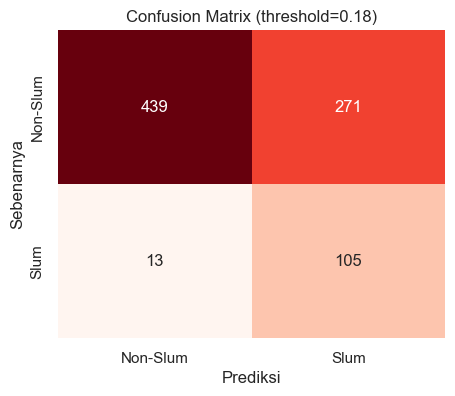

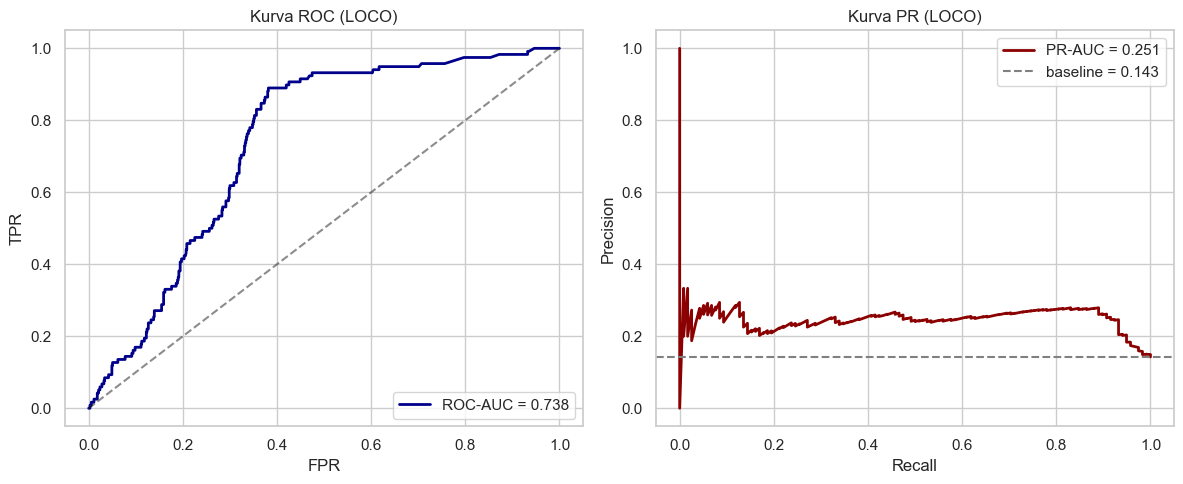


=== Performa per kota (model dilatih kota lain) ===
     kota   n  slum  PR_AUC  ROC_AUC
    ambon  50    15   0.708    0.882
      dki 261    62   0.245    0.488
  kebumen 458    27   0.248    0.759
samarinda  59    14   0.447    0.698


In [8]:
prec, rec, thr = precision_recall_curve(y, oof_tuned)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_t = float(thr[np.argmax(f1[:-1])]) if len(thr) else 0.5
y_hat = (oof_tuned >= best_t).astype(int)

print(f"Threshold optimal (F1) = {best_t:.3f}\n")
print("=== Laporan Klasifikasi (prediksi out-of-fold LOCO) ===")
print(classification_report(y, y_hat, target_names=['Non-Slum', 'Slum']))

# Confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y, y_hat), annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Non-Slum','Slum'], yticklabels=['Non-Slum','Slum'])
plt.title(f'Confusion Matrix (threshold={best_t:.2f})')
plt.xlabel('Prediksi'); plt.ylabel('Sebenarnya'); plt.show()

# Kurva ROC & PR (LOCO)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fpr, tpr, _ = roc_curve(y, oof_tuned)
axes[0].plot(fpr, tpr, color='darkblue', lw=2,
             label=f'ROC-AUC = {roc_auc_score(y, oof_tuned):.3f}')
axes[0].plot([0,1],[0,1],'k--',alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('Kurva ROC (LOCO)')
axes[0].legend(loc='lower right')
axes[1].plot(rec, prec, color='darkred', lw=2,
             label=f'PR-AUC = {average_precision_score(y, oof_tuned):.3f}')
axes[1].axhline(y.mean(), ls='--', color='gray', label=f'baseline = {y.mean():.3f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('Kurva PR (LOCO)')
axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()

# Rincian per kota
print("\n=== Performa per kota (model dilatih kota lain) ===")
per_city = []
for c in sorted(np.unique(groups)):
    m = groups == c
    per_city.append({
        'kota': c, 'n': int(m.sum()), 'slum': int(y[m].sum()),
        'PR_AUC': round(average_precision_score(y[m], oof_tuned[m]), 3) if y[m].sum() > 0 else None,
        'ROC_AUC': round(roc_auc_score(y[m], oof_tuned[m]), 3) if len(np.unique(y[m])) > 1 else None,
    })
print(pd.DataFrame(per_city).to_string(index=False))

## 8. Interpretabilitas (Hanya Fitur Bangunan)

Model final di-fit pada **seluruh** data hanya untuk interpretasi (importance & SHAP) -- **bukan**
untuk skor (skor jujur sudah dari LOCO di atas). Karena `city` tidak menjadi fitur, plot di bawah
murni menunjukkan fitur **bangunan** yang paling berpengaruh.

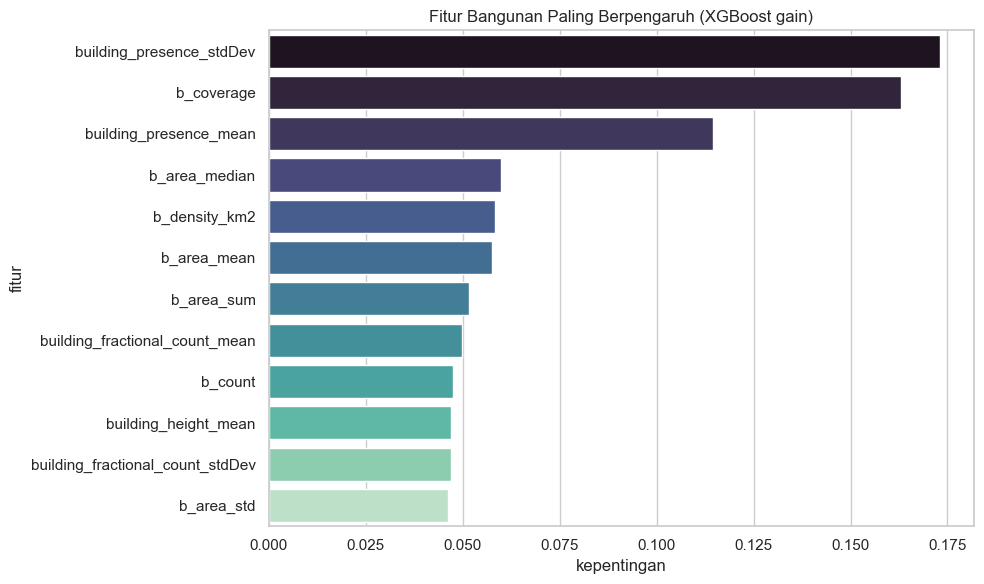

--- Menghitung SHAP values ---


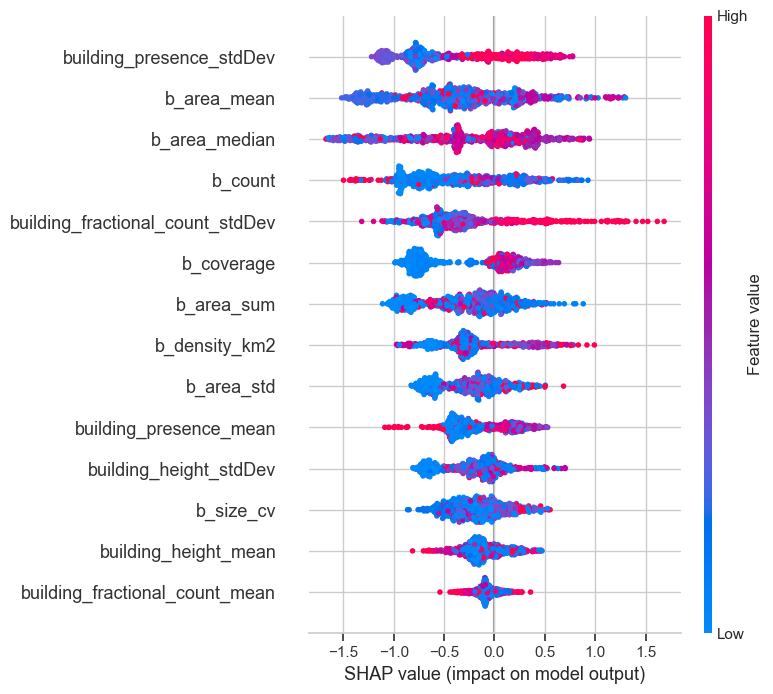

In [9]:
final = make_xgb(spw_all).fit(X, y)
clf = final.named_steps['clf']

# Importance bawaan XGBoost (gain)
imp = (pd.DataFrame({'fitur': FEATURES, 'kepentingan': clf.feature_importances_})
       .sort_values('kepentingan', ascending=False))
plt.figure(figsize=(10, 6))
sns.barplot(data=imp.head(12), x='kepentingan', y='fitur', hue='fitur',
            palette='mako', legend=False)
plt.title('Fitur Bangunan Paling Berpengaruh (XGBoost gain)')
plt.tight_layout(); plt.show()

# SHAP
print("--- Menghitung SHAP values ---")
X_imp = final.named_steps['imp'].transform(X)
explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(X_imp)
shap.summary_plot(shap_vals, X_imp, feature_names=FEATURES)

## 9. Pipeline Inferensi (Prediksi Data Baru)

In [10]:
def prediksikan_area_baru(df_baru, model_pipeline=final, features=FEATURES, threshold=best_t):
    """Terima data baru (kolom fitur bangunan sama), keluarkan probabilitas & kelas slum."""
    proba = model_pipeline.predict_proba(df_baru[features])[:, 1]
    out = df_baru.copy()
    out['Probabilitas_Slum'] = proba
    out['Prediksi_Status_Slum'] = (proba >= threshold).astype(int)
    return out

contoh = df.head(4).copy()
hasil = prediksikan_area_baru(contoh)
cols_show = ['city', 'b_density_km2', 'building_height_mean',
             'Probabilitas_Slum', 'Prediksi_Status_Slum']
hasil[[c for c in cols_show if c in hasil.columns]]

,city,b_density_km2,building_height_mean,Probabilitas_Slum,Prediksi_Status_Slum
0,ambon,761.273292,0.565792,0.015858,0
1,ambon,774.232211,0.500697,0.007566,0
2,ambon,234.086584,0.189191,0.000445,0
3,ambon,480.395608,0.558317,0.005638,0


## 10. Kesimpulan

- **Murni indikator bangunan.** `city` hanya untuk grouping, bukan fitur -> klaim "Indikator 1:
  Bangunan" tidak bocor ke prevalensi kota maupun indikator lain.
- **Skor jujur.** PR-AUC dari LOCO (Bagian 6) adalah angka yang layak diklaim ke juri; bandingkan
  dengan PR-AUC split acak untuk melihat seberapa besar split acak menggelembungkan skor.
- **Seleksi fitur berbasis bukti, tanpa bias.** Himpunan fitur pelaporan ditetapkan di awal
  (`USE_NDBI`, default 14 footprint murni). Tabel ablation (Bagian 5) mengukur berapa informasi
  yang berubah jika NDBI built-up ditambahkan -- itu jawaban atas "apakah 14 fitur membuang
  informasi". Pilih sesuai definisi Indikator 1 di lomba dengan membalik satu flag.
- **Imbalance ditangani benar.** Metrik utama PR-AUC + recall, `scale_pos_weight` per-fold, dan
  threshold dioptimalkan dari out-of-fold (bukan 0.5).